<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/examples/BE3Dv8_MultiScreen_MORC2_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
https://github.com/broadinstitute/BE3D

# Setup

In [ ]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,929 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,015 kB]
Get:

In [ ]:
# @title Install MUSCLE

! wget https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
! chmod +x muscle-linux-x86.v5.3
! mv muscle-linux-x86.v5.3 muscle


--2026-04-20 04:38:19--  https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/378508080/9dc41df9-b517-49e5-8af6-0cab933dbe43?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-20T05%3A36%3A55Z&rscd=attachment%3B+filename%3Dmuscle-linux-x86.v5.3&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-20T04%3A36%3A13Z&ske=2026-04-20T05%3A36%3A55Z&sks=b&skv=2018-11-09&sig=6gHQrRLVrK3v0SNP%2FKUFLgPQlKQ2RtEpLp6cNTUy0GE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NjY2MDE5OSwibmJmIjoxNzc2NjU5ODk5LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGl

In [ ]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-bbvf48w2
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-bbvf48w2
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit b581cc74109f7c4fbfdaefc516963fe640554583
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.4 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=764523 sha256=72cddda7678c39c36fb02cb865795860e0f2b9510e5baf7ca7a42b236022d551
  Stored in directory: /tmp/pip-ephem-wheel-cache-qq9vcmu8/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filename=

In [ ]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

plt.rcParams['font.family'] = 'DejaVu Sans'


In [ ]:
# @title Download relevant files for running BE3D

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py -O be3d_display_yaml.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py -O be3d_helper.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_qa.py -O be3d_qa.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_calculate_lfc3d.py -O beclust3d_calculate_lfc3d.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_nonaggregate.py -O beclust3d_nonaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_characterization.py -O beclust3d_characterization.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_metaaggregate.py -O bemetaclust3d_metaaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_characterization.py -O bemetaclust3d_characterization.py


--2026-04-20 04:38:46--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18139 (18K) [text/plain]
Saving to: ‘be3d_display_yaml.py’

be3d_display_yaml.p 100%[===================>]  17.71K  --.-KB/s    in 0.001s  

2026-04-20 04:38:46 (19.3 MB/s) - ‘be3d_display_yaml.py’ saved [18139/18139]

--2026-04-20 04:38:46--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

# BE3D Inputs (MORC2)

In [ ]:
# @title Download relevant files for MORC2

! mkdir MORC2/
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MORC2-Griffin.yaml -O MORC2/MORC2-Griffin.yaml
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/pdb/Q9Y6X9.pdb -O MORC2/Q9Y6X9.pdb


mkdir: cannot create directory ‘MORC2/’: File exists
--2026-04-20 04:47:38--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MORC2-Griffin.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9125 (8.9K) [text/plain]
Saving to: ‘MORC2/MORC2-Griffin.yaml’

MORC2/MORC2-Griffin 100%[===================>]   8.91K  --.-KB/s    in 0s      

2026-04-20 04:47:38 (62.4 MB/s) - ‘MORC2/MORC2-Griffin.yaml’ saved [9125/9125]

--2026-04-20 04:47:38--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/pdb/Q9Y6X9.pdb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.1

In [ ]:
# @title Display Input .yaml File

from be3d_display_yaml import display_yaml_config

# @markdown Path to downloaded or user-input .yaml configuration file
yaml_config_filepath = "MORC2/MORC2-Griffin.yaml" # @param {type:"string"}
display_yaml_config(yaml_config_filepath)

with open(yaml_config_filepath, 'r') as file:
    input_dict = yaml.safe_load(file)

output_dir = input_dict['output_dir']
input_gene = input_dict['input_gene']

# @markdown To edit BE3D inputs, open the Files tab, open the yaml config file, change the variables, and save the file.


# BE3D Run (MORC2)

MORC2/MORC2-Griffin.yaml and /content/MORC2/MORC2-Griffin.yaml are the same file.
All results will be saved in the following directory: /content/MORC2/

muscle 5.3.linux64 [d9725ac]  13.3Gb RAM, 2 cores
Built Nov 10 2024 22:58:59
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

[align /content/MORC2/conservation/sequences.fasta]
Input: 2 seqs, avg length 1031, max 1032, min 1030

00:00 4.6Mb   100.0% Derep 2 uniques, 0 dupes
00:00 4.6Mb  CPU has 2 cores, running 1 threads
00:00 4.6Mb   100.0% Calc posteriors
00:00 4.7Mb   100.0% UPGMA5         
Output from beclust3d.lfc3d.conservation is saved in the following directory: /content/MORC2/conservation/
Output from beclust3d.lfc3d.structure is saved in the following directory: /content/MORC2/sequence_structure/
Output from beclust3d.qc.hypothesis_tests is saved in the following directory: /content/MORC2/hypothesis_qc/
BE-QA complete: sequence/structural features and hypothesis tests


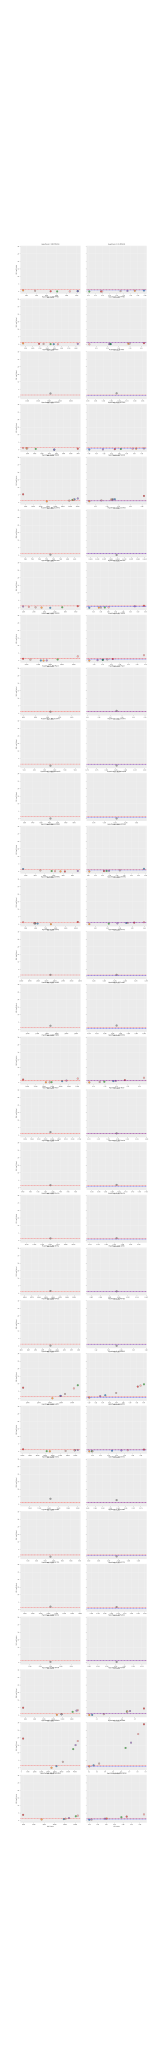

In [ ]:
# @title BE-QA and Visualizations
# @markdown Description

! python be3d_qa.py {yaml_config_filepath}

display(SVG(filename=f'{output_dir}hypothesis_qc/hypothesis2_scatterplot_by_gene_name.svg'))


All results will be saved in the following directory: /content/MORC2/
Processing Human_InVitro_HS294T_Apobec_D24_Input
{'Nonsense': 29, 'Splice Site': 11, 'Missense': 235, 'Silent': 94, 'No Mutation': 147, 'Intron': 62}
Processing Human_InVitro_HS294T_TadA_D14_Input
{'Splice Site': 17, 'Missense': 288, 'Silent': 54, 'No Mutation': 153, 'Intron': 67}
Processing Human_InVitro_SK-ES_Apobec_D23_Input
{'Nonsense': 29, 'Splice Site': 11, 'Missense': 235, 'Silent': 94, 'No Mutation': 147, 'Intron': 62}
Processing Human_InVitro_SK-ES_TadA_D17_Input
{'Splice Site': 17, 'Missense': 288, 'Silent': 54, 'No Mutation': 153, 'Intron': 67}
Processing Human_InVitro_SW480_Apobec_D14_Input
{'Nonsense': 29, 'Splice Site': 11, 'Missense': 235, 'Silent': 94, 'No Mutation': 147, 'Intron': 62}
Processing Human_InVitro_SW480_TadA_D14_Input
{'Splice Site': 17, 'Missense': 288, 'Silent': 54, 'No Mutation': 153, 'Intron': 67}
Processing Human_InVitro_SW480flow_Apobec_D10_Enriched
{'Nonsense': 29, 'Splice Site': 1

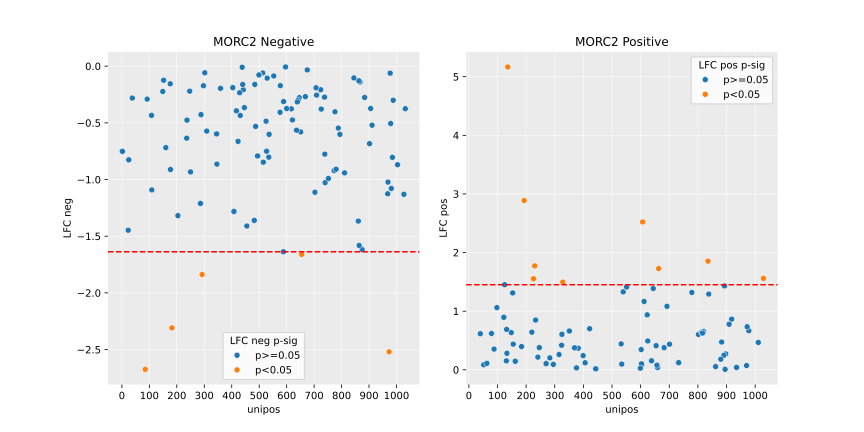

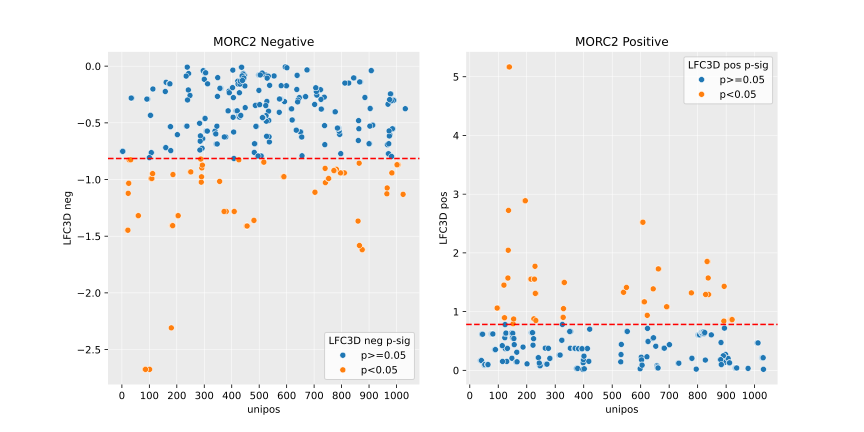

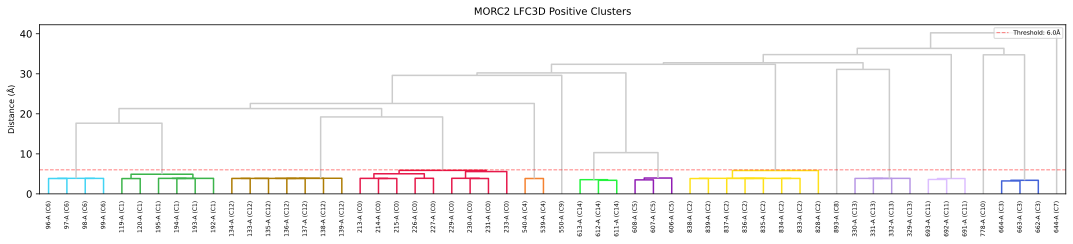

In [ ]:
# @title BE-Clust3D and Visualizations
# @markdown Description

! python beclust3d_calculate_lfc3d.py {yaml_config_filepath}
! python beclust3d_nonaggregate.py {yaml_config_filepath}

screen_name = 'Human_InVitro_HS294T_Apobec_D24_Input'
display(SVG(filename=f'{output_dir}LFC/plots/{input_gene}_{screen_name}_LFC_cutoff05_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}LFC3D/plots/{input_gene}_{screen_name}_LFC3D_cutoff05_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene}_{screen_name}_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))


All results will be saved in the following directory: /content/MORC2/
Output from beclust3d.lfc3d.characterization is saved in the following directory: /content/MORC2/characterization/
Step 3b complete: per-screen characterization done


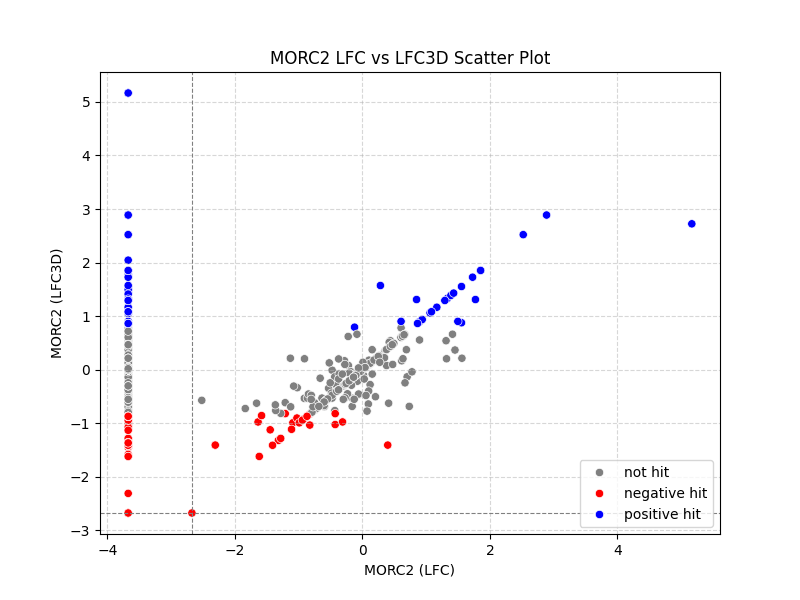

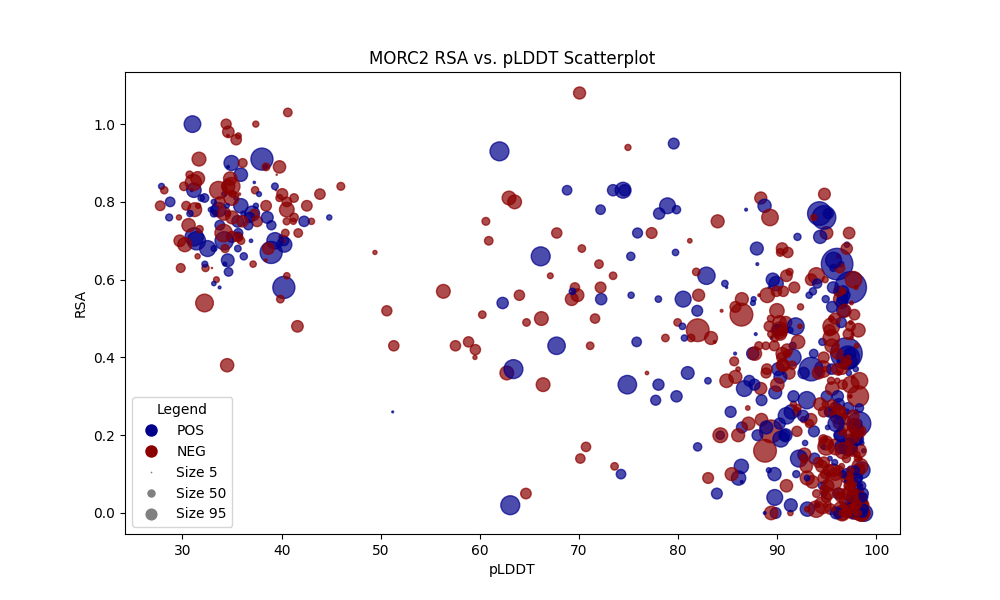

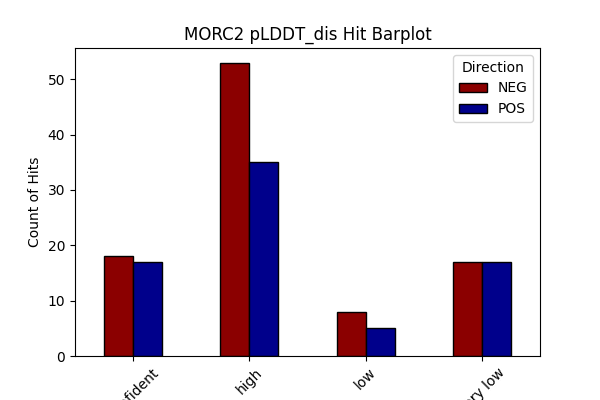

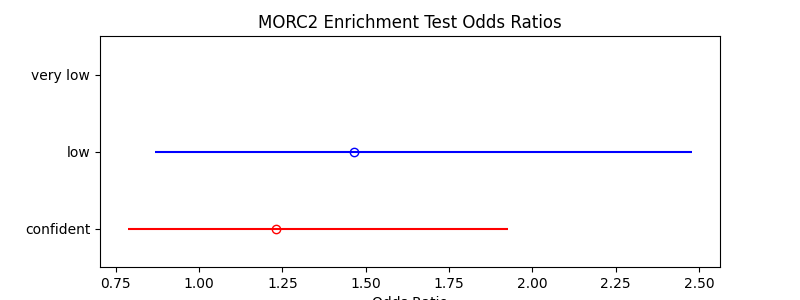

In [ ]:
# @title BEClust3D Characterization and Visualizations

! python beclust3d_characterization.py {yaml_config_filepath}

screen_name = 'Human_InVitro_HS294T_Apobec_D24_Input'
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05_{screen_name}.png'))


In [ ]:
# @title BE-MetaClust3D and Visualizations
# @markdown Description

! python bemetaclust3d_metaaggregate.py {yaml_config_filepath}

input_gene_temp = 'Merged'
display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene_temp}_LFC_cutoff001_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene_temp}_LFC3D_cutoff001_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene_temp}_Meta_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))


All results will be saved in the following directory: /content/MORC2/
Output from beclust3d.aggregate.metaaggregate is saved in the following directory: /content/MORC2/meta-aggregate/
Output from beclust3d.aggregate.aggregate_plot is saved in the following directory: /content/MORC2/meta-aggregate/


All results will be saved in the following directory: /content/MORC2/
MORC2 Human_InVitro_HS294T_Apobec_D24_Input
MORC2 Human_InVitro_HS294T_TadA_D14_Input
MORC2 Human_InVitro_SK-ES_Apobec_D23_Input
MORC2 Human_InVitro_SK-ES_TadA_D17_Input
MORC2 Human_InVitro_SW480_Apobec_D14_Input
MORC2 Human_InVitro_SW480_TadA_D14_Input
MORC2 Human_InVitro_SW480flow_Apobec_D10_Enriched
MORC2 Human_InVitro_SW480flow_Apobec_D10_Input1
MORC2 Human_InVitro_SW480flow_Apobec_Enriched_Input2
MORC2 Human_InVitro_SW480flow_TadA_D10_Enriched
MORC2 Human_InVitro_SW480flow_TadA_D10_Input
MORC2 Human_InVitro_SW480repeat_Apobec_D7_Input
MORC2 Human_InVitro_SW480repeat_TadA_D7_Input
Morc2a Mouse_InVitro_B16_TadA_D14-IFNg_Input
Morc2a Mouse_InVivo_LLC_Apobec_Tx_NSG
Output from beclust3d.lfc3d.characterization is saved in the following directory: /content/MORC2/characterization/
Step 3b complete: meta characterization done


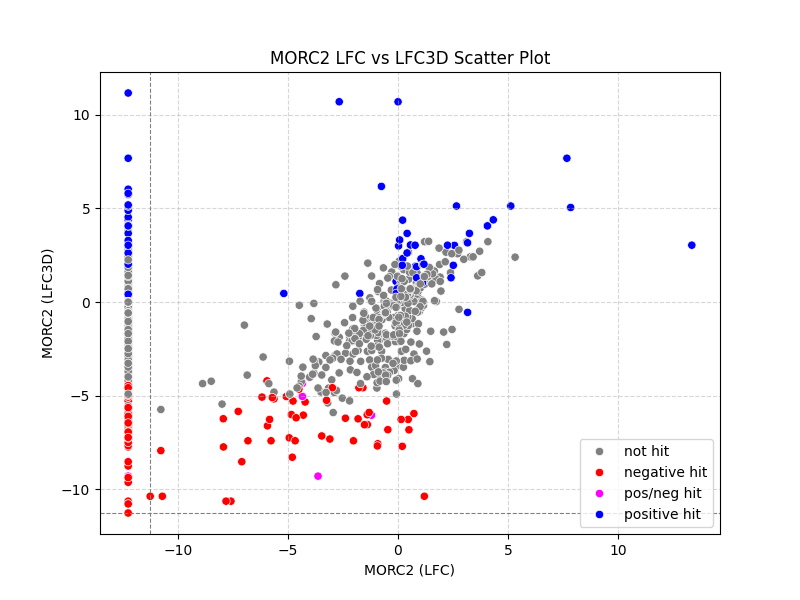

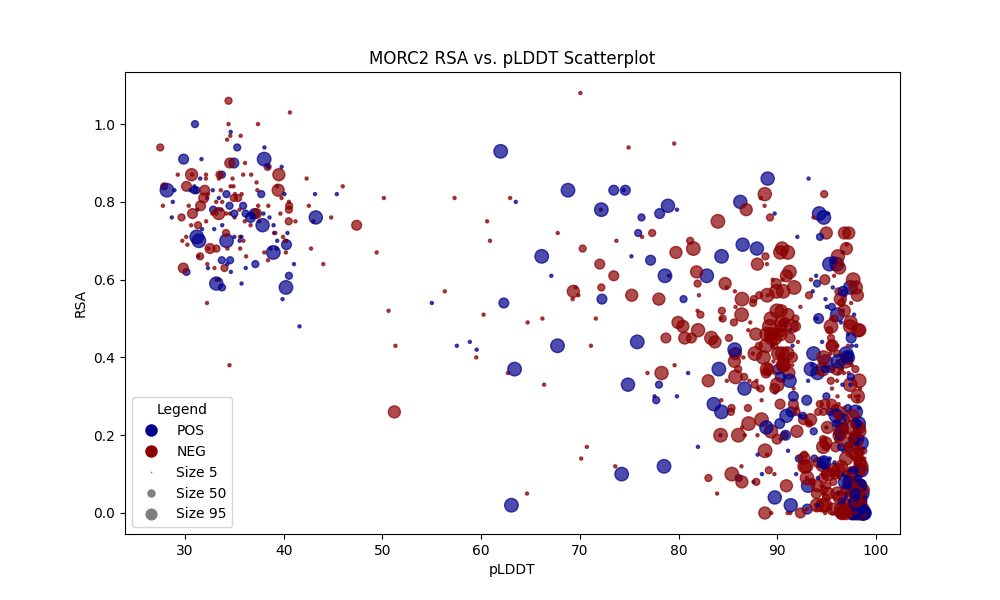

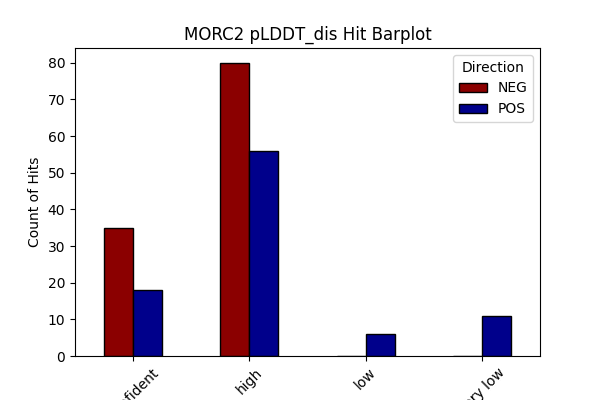

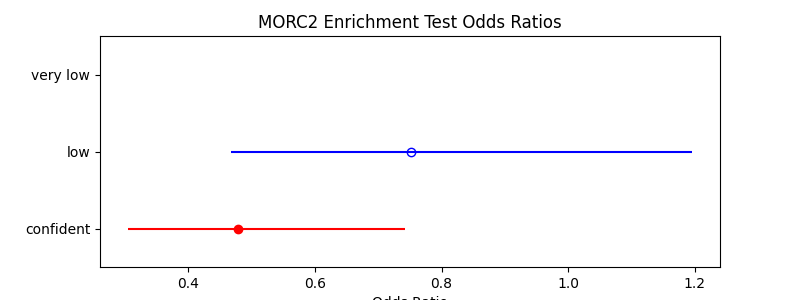

In [ ]:
# @title BE-MetaClust3D Characterization and Visualizations

! python bemetaclust3d_characterization.py {yaml_config_filepath}

input_gene = 'MORC2'
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_001_Meta.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_001.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_001.png'))
